# Building a Simple Neural Network


In [3]:
# --- Setup: Clone repo & cd into correct folder (for lab setup convenience) ---
import os
import subprocess

repo_url = "https://github.com/HassanAlgoz/learn-pytorch.git"
lab_folder = "learn-pytorch/C1_M1_Getting_Started/C1_M1_Lab_1_simple_nn"

# Only clone if the folder doesn't exist
if not os.path.exists(lab_folder):
    subprocess.run(["git", "clone", repo_url])
    # If repo structure differs, modify below:
    # Or cd into repo, e.g. os.chdir("your-repo")

# Change working directory to the lab folder
os.chdir(lab_folder)

Import helpers:

In [8]:
# Used for plotting and testing results without bloating the lab notebook
import helper_utils

## Imports

- `torch` — core library
- `torch.nn` — neural network layers
- `torch.optim` — optimizers


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# Ensure results are reproducible
torch.manual_seed(42)

## The Delivery Problem

**Question:** Can a 7-mile delivery finish in under 30 minutes?


## Tensors

PyTorch stores data in **tensors** — multi-dimensional arrays built for numerical computation.


In [ ]:
# Distances in miles for recent bike deliveries
distances = torch.tensor(
  [
    [2.0], [3.0], [4.0], [5.0], [6.0]
  ],
  dtype=torch.float32
)

# Corresponding delivery times in minutes
times = torch.tensor(
  [
    [11.9], [15.3], [18.8], [22.2], [25.6]
  ],
  dtype=torch.float32
)

In [ ]:
distances.shape

In [ ]:
times.shape

### Exercise: create tensors

Define `distances` and `times` as [tensors](https://docs.pytorch.org/docs/stable/tensors.html) with `dtype=torch.float32`:


| Distance (miles) | Delivery Time (minutes) |
| :--- | :--- |
| 1.0 | 6.96 |
| 2.0 | 12.11 |
| 3.0 | 16.77 |
| 4.0 | 22.21 |


In [ ]:
# INSERT YOUR CODE HERE

### Exercise: check shapes

Assert that both tensors have the same number of rows. Error message: `"Each distance must have a corresponding time"`.


In [ ]:
# INSERT YOUR CODE HERE

```python
# Hint
assert final_price >= 0, "Price cannot be negative"
```


Shape: `(batch_size, num_features)`. Here each sample has one feature, so shape is `(5, 1)`.


## Model

A single linear neuron: `time ≈ weight * distance + bias`.


In [13]:
eight_inputs_model = nn.Sequential(
  nn.Linear(in_features=8, out_features=1)
)

### Exercise: build the model

Create a model with 1 input (distance) and 1 output (time):


In [14]:
# INSERT YOUR CODE HERE
model = nn.Sequential(
  nn.Linear(1, 1)
)

### Training


In [15]:
# Define the loss function and optimizer
loss_function = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

In [16]:
# Training loop
for epoch in range(500):
    # Reset the optimizer's gradients
    optimizer.zero_grad()

    # Make predictions (forward pass)
    outputs = model(distances)

    # Calculate the loss
    # Remember:
    # outputs: predicted target
    #   times: actual/true target
    loss = loss_function(outputs, times)

    # Calculate adjustments (backward pass)
    loss.backward()

    # Update the model's parameters (through the optimizer)
    optimizer.step()

    # Print loss every 50 epochs (to see the progress)
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch + 1}: Loss = {loss.item()}")

Epoch 50: Loss = 1.2553919553756714
Epoch 100: Loss = 1.0157527923583984
Epoch 150: Loss = 0.8218797445297241
Epoch 200: Loss = 0.6650332808494568
Epoch 250: Loss = 0.5381405353546143
Epoch 300: Loss = 0.435481458902359
Epoch 350: Loss = 0.3524280786514282
Epoch 400: Loss = 0.28523683547973633
Epoch 450: Loss = 0.2308768481016159
Epoch 500: Loss = 0.186899334192276


> Interactive training loop: https://nnplayground.com/


### Visualize

Plot data points vs. the learned line:


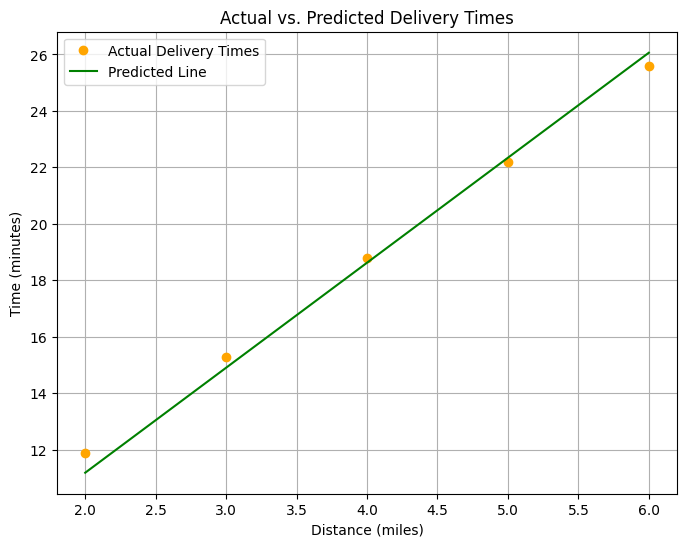

In [17]:
helper_utils.plot_results(model, distances, times)

### Predict

Use the trained model (**inference**) to predict time for a new distance.

Set `distance_to_predict` (start with `7.0`):


In [18]:
distance_to_predict = 7.0

Wrap inference in `torch.no_grad()` (no gradients needed). Input must be 2D: `[[7.0]]`.


In [19]:
# Use the torch.no_grad() context manager for efficient predictions
with torch.no_grad():
    # Convert the Python variable into a 2D PyTorch tensor that the model expects
    new_distance = torch.tensor([[distance_to_predict]], dtype=torch.float32)

    # Pass the new data to the trained model to get a prediction
    predicted_time = model(new_distance)

    # Use .item() to extract the scalar value from the tensor for printing
    print(f"Prediction for a {distance_to_predict}-mile delivery: {predicted_time.item():.1f} minutes")

    # Use the scalar value in a conditional statement to make the final decision
    if predicted_time.item() > 30:
        print("\nDecision: Do NOT take the job. You will likely be late.")
    else:
        print("\nDecision: Take the job. You can make it!")

Prediction for a 7.0-mile delivery: 29.8 minutes

Decision: Take the job. You can make it!


A 7-mile delivery is predicted over 30 minutes — decline the job.


## Inspect parameters

Read the learned weight and bias:


In [20]:
# Access the first (and only) layer in the sequential model
layer = model[0]

# Get weights and bias
weights = layer.weight.data.numpy()
bias = layer.bias.data.numpy()

print(f"Weight: {weights}")
print(f"Bias: {bias}")

Weight: [[3.7187986]]
Bias: [3.7480488]


**Interpretation**

- **Weight (~5.0):** minutes added per mile
- **Bias (~2.0):** fixed overhead (pickup, start)

`Time ≈ 5.0 × Distance + 2.0`


## Harder data

Deliveries over 3 miles now go by car. The dataset mixes bike and car trips — does the linear model still fit?


In [21]:
# Combined dataset: bikes for short distances, cars for longer ones
new_distances = torch.tensor([
    [1.0], [1.5], [2.0], [2.5], [3.0], [3.5], [4.0], [4.5], [5.0], [5.5],
    [6.0], [6.5], [7.0], [7.5], [8.0], [8.5], [9.0], [9.5], [10.0], [10.5],
    [11.0], [11.5], [12.0], [12.5], [13.0], [13.5], [14.0], [14.5], [15.0], [15.5],
    [16.0], [16.5], [17.0], [17.5], [18.0], [18.5], [19.0], [19.5], [20.0]
], dtype=torch.float32)

# Corresponding delivery times in minutes
new_times = torch.tensor([
    [6.96], [9.67], [12.11], [14.56], [16.77], [21.7], [26.52], [32.47], [37.15], [42.35],
    [46.1], [52.98], [57.76], [61.29], [66.15], [67.63], [69.45], [71.57], [72.8], [73.88],
    [76.34], [76.38], [78.34], [80.07], [81.86], [84.45], [83.98], [86.55], [88.33], [86.83],
    [89.24], [88.11], [88.16], [91.77], [92.27], [92.13], [90.73], [90.39], [92.98]
], dtype=torch.float32)

Predict on `new_distances` with the trained model:


In [22]:
# Use the already-trained linear model to make predictions
with torch.no_grad():
    predictions = model(new_distances)

Compute loss on the new data (expect it to be much higher):


In [23]:
# Calculate the new loss
new_loss = loss_function(predictions, new_times)
print(f"Loss on new, combined data: {new_loss.item():.2f}")

Loss on new, combined data: 563.65


Visualize the mismatch:


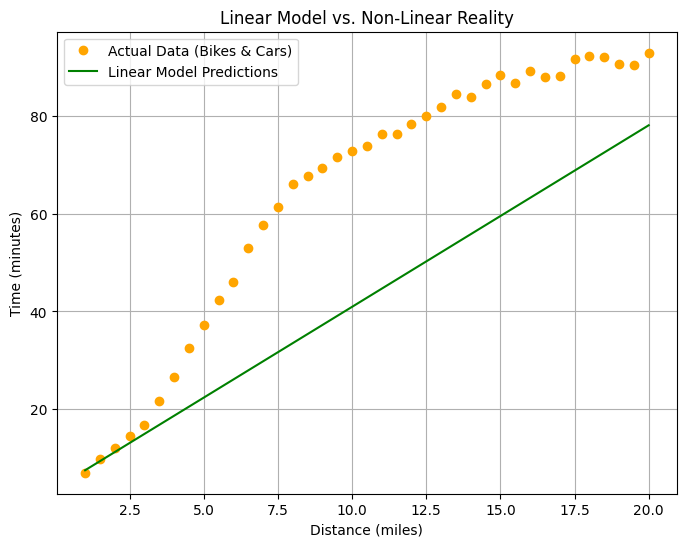

In [24]:
helper_utils.plot_nonlinear_comparison(model, new_distances, new_times)

**Why it fails:** bike+car data is non-linear; a straight line cannot fit both regimes.

Next: **activation functions** — so networks can learn curves, not just lines.


## Conclusion

You trained a linear model that worked on simple data and failed on non-linear data. Next lesson: activation functions.
